We used Gemini and Claude to help with the coding

In [243]:
import pandas as pd
import numpy as np

In [244]:
df = pd.read_csv("master_data_2020.csv")
df_raw = pd.read_csv("master_data_2020.csv")
df = df[~df["presvote20post"].isna()]




treatment = "untrustworthy_flag"
raw_vote_choice_col = "presvote20post"





vote_series = df[raw_vote_choice_col].astype(str).str.strip()


df["voted_biden_2020"] = np.where(vote_series == "Joe Biden", 1, 0)


df["voted_trump_2020"] = np.where(vote_series == "Donald Trump", 1, 0)



df["turnout_2020_binary"] = np.where(
    vote_series.str.contains("did not vote|skipped|__na__", case=False, na=True),
    0,
    1
)


outcomes = {
    "2020 Turnout": "turnout_2020_binary",
    "Voted for Biden": "voted_biden_2020",
    "Voted for Trump": "voted_trump_2020",
}





tf_cols = ["tf_adv", "tf_pdf", "tf_spy", "tf_wiki", "tf_cache", "tf_phishing"]
df_tf = df[tf_cols].map(
    lambda val: int(str(val).strip().split()[0])
    if pd.notna(val) and str(val).strip().split()[0].isdigit()
    else np.nan
)
df["digital_literacy_index"] = df_tf.mean(axis=1)


df["ideo5_linear"] = df["ideo5"].map({"Very liberal": 1, "Liberal": 2, "Moderate": 3, "Conservative": 4, "Very conservative": 5})
df["pid7_linear"] = df["pid7"].map({"Strong Democrat": 1, "Not very strong Democrat": 2, "Lean Democrat": 3, "Independent": 4, "Lean Republican": 5, "Not very strong Republican": 6, "Strong Republican": 7})


socmed_mapping = {
    "Less than 10 minutes per day": 1, "10–30 minutes per day": 2, "31–60 minutes per day": 3,
    "1–2 hours per day": 4, "2–3 hours per day": 5, "More than 3 hours per day": 6
}
df["socmed_use_linear"] = df["socmed_use"].astype(str).str.strip().map(socmed_mapping)


newsint_mapping = {
    "Hardly at all": 1,
    "Only now and then": 2,
    "Some of the time": 3,
    "Most of the time": 4
}
df["newsint_linear"] = df["newsint"].astype(str).str.strip().map(newsint_mapping)


intuse_mapping = {
    "Less often": 1,
    "About once a day": 3,
    "Several times a day": 4,
    "A few times a week": 2  
}

df["intuse_linear"] = df["intuse"].astype(str).str.strip().map(intuse_mapping).fillna(3)



def condense_2016_vote_fixed(val):
    val_str = str(val).strip()
    if val_str in ["Hillary Clinton", "Donald Trump"]:
        return val_str
    
    elif pd.isna(val) or val_str in ["__NA__", "nan", "Did not vote", "Did not vote for President"]:
        return "Did Not Vote"
    else:
        return "Other"

df["presvote16post_condensed"] = df["presvote16post"].apply(condense_2016_vote_fixed)



categorical_covariates = [
    "race4", 
    "educ4", 
    "region", 
    "presvote16post_condensed" 
]

linear_features = [
    "ideo5_linear", 
    "pid7_linear", 
    "socmed_use_linear", 
    "newsint_linear", 
    "intuse_linear"
]




core_cols = [treatment] + list(outcomes.values()) + ["age", "female"]
engineered_continuous = ["digital_literacy_index"]



all_processed_cols = core_cols + engineered_continuous + linear_features + categorical_covariates
df_clean = df[all_processed_cols].dropna().copy()



X_matrix = pd.get_dummies(
    df_clean[["age", "female"] + engineered_continuous + linear_features + categorical_covariates],
    columns=categorical_covariates,
    drop_first=False,
    dtype=int,
)


baselines_to_drop = [
    'presvote16post_condensed_Donald Trump',  
    'race4_White',                            
    'educ4_College grad',                     
    'region_Midwest',                         
]


X_matrix = X_matrix.drop(columns=baselines_to_drop, errors='ignore')




W = df_clean[treatment].astype(int).values
Y_turnout = df_clean[outcomes["2020 Turnout"]].astype(int).values
Y_biden = df_clean[outcomes["Voted for Biden"]].astype(int).values
Y_trump = df_clean[outcomes["Voted for Trump"]].astype(int).values


raw_post_weights = df.loc[X_matrix.index, "weight_post"].fillna(1.0).values


lower_bound = np.percentile(raw_post_weights, 5)
upper_bound = np.percentile(raw_post_weights, 95)


trimmed_post_weights = np.clip(raw_post_weights, lower_bound, upper_bound)


survey_weights = trimmed_post_weights / np.mean(trimmed_post_weights)

In [245]:
print("--- SURVEY WEIGHT DIAGNOSTICS ---")
print(f"Min Weight:     {survey_weights.min():.4f}")
print(f"Max Weight:     {survey_weights.max():.4f}")
print(f"Mean Weight:    {survey_weights.mean():.4f}")
print(f"Std Dev Weight: {survey_weights.std():.4f}")


print(f"Max/Mean Ratio: {survey_weights.max() / survey_weights.mean():.2f}")

--- SURVEY WEIGHT DIAGNOSTICS ---
Min Weight:     0.1159
Max Weight:     3.3223
Mean Weight:    1.0000
Std Dev Weight: 0.8259
Max/Mean Ratio: 3.32


In [246]:

import scipy.stats as stats
from sklearn.ensemble import RandomForestClassifier


X = X_matrix.values
N = len(W)

candidate_outcomes = {"Voted for Biden": Y_biden, "Voted for Trump": Y_trump}


np.random.seed(42)
indices = np.arange(N)
np.random.shuffle(indices)

num_folds = 5
folds = np.array_split(indices, num_folds)


n_estimators = 100
max_depth = 10
min_samples_leaf = 10

for name, Y in candidate_outcomes.items():
    
    e_hat = np.zeros(N)
    mu_1_hat = np.zeros(N)
    mu_0_hat = np.zeros(N)

    for f in range(num_folds):
        val_idx = folds[f]
        train_idx = np.setdiff1d(indices, val_idx)

        X_train, X_val = X[train_idx], X[val_idx]
        W_train, W_val = W[train_idx], W[val_idx]
        Y_train, Y_val = Y[train_idx], Y[val_idx]

        
        w_train = survey_weights[train_idx]
        w_train = w_train / np.mean(w_train)  

        
        
        
        prop_model = RandomForestClassifier(
            n_estimators=n_estimators, 
            max_depth=max_depth, 
            min_samples_leaf=min_samples_leaf,
            random_state=42, 
            n_jobs=-1
        )
        
        prop_model.fit(X_train, W_train, sample_weight=w_train)
        e_hat[val_idx] = prop_model.predict_proba(X_val)[:, 1]

        
        
        
        
        treated_mask = W_train == 1
        w_train_1 = w_train[treated_mask] / np.mean(w_train[treated_mask])  
        
        out_model_1 = RandomForestClassifier(
            n_estimators=n_estimators, 
            max_depth=max_depth, 
            min_samples_leaf=min_samples_leaf,
            random_state=42, 
            n_jobs=-1
        )
        out_model_1.fit(X_train[treated_mask], Y_train[treated_mask], sample_weight=w_train_1)
        mu_1_hat[val_idx] = out_model_1.predict_proba(X_val)[:, 1]

        
        control_mask = W_train == 0
        w_train_0 = w_train[control_mask] / np.mean(w_train[control_mask])  
        
        out_model_0 = RandomForestClassifier(
            n_estimators=n_estimators, 
            max_depth=max_depth, 
            min_samples_leaf=min_samples_leaf,
            random_state=42, 
            n_jobs=-1
        )
        out_model_0.fit(X_train[control_mask], Y_train[control_mask], sample_weight=w_train_0)
        mu_0_hat[val_idx] = out_model_0.predict_proba(X_val)[:, 1]

    
    
    
    e_hat = np.clip(e_hat, 0.05, 0.95)

    base_diff = mu_1_hat - mu_0_hat
    treated_correction = (W * (Y - mu_1_hat)) / e_hat
    control_correction = ((1 - W) * (Y - mu_0_hat)) / (1 - e_hat)

    
    aipw_scores = base_diff + treated_correction - control_correction
    
    
    population_ate = np.average(aipw_scores, weights=survey_weights)

    
    influence_curve = survey_weights * (aipw_scores - population_ate)
    variance = np.sum(influence_curve**2) / (N**2)
    std_error = np.sqrt(variance)

    
    z_stat = population_ate / std_error
    p_val = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
    ci_lower = population_ate - (1.96 * std_error)
    ci_upper = population_ate + (1.96 * std_error)

    print(f"  ATE: {population_ate:+.4f} ({population_ate*100:+.2f} percentage points)")
    print(f"  Std Error: {std_error:.4f}")
    print(f"  95% CI:   [{ci_lower:+.4f}, {ci_upper:+.4f}]")
    print(f"  p-value:   {p_val:.4f}")

  ATE: -0.0367 (-3.67 percentage points)
  Std Error: 0.0222
  95% CI:   [-0.0803, +0.0069]
  p-value:   0.0986
  ATE: +0.0657 (+6.57 percentage points)
  Std Error: 0.0252
  95% CI:   [+0.0163, +0.1152]
  p-value:   0.0092


In [247]:




treated_mask = (df_clean[treatment] == 1).values
control_mask = (df_clean[treatment] == 0).values


continuous_features = [
    "age", "female", "digital_literacy_index", 
    "ideo5_linear", "pid7_linear", "socmed_use_linear", 
    "newsint_linear", "intuse_linear"
]
categorical_features = ["race4", "educ4", "presvote16post_condensed"]

balance_rows = []


for col in continuous_features:
    vals_t = df_clean.loc[treated_mask, col].values
    vals_c = df_clean.loc[control_mask, col].values
    
    w_t = survey_weights[treated_mask]
    w_c = survey_weights[control_mask]
    
    
    mean_t = np.average(vals_t, weights=w_t)
    mean_c = np.average(vals_c, weights=w_c)
    
    
    var_t = np.average((vals_t - mean_t)**2, weights=w_t)
    var_c = np.average((vals_c - mean_c)**2, weights=w_c)
    
    pooled_sd = np.sqrt((var_t + var_c) / 2)
    smd = (mean_t - mean_c) / pooled_sd if pooled_sd > 0 else 0
    
    balance_rows.append({
        "Feature": col,
        "Treated Mean": f"{mean_t:.2f}",
        "Control Mean": f"{mean_c:.2f}",
        "SMD": f"{smd:+.3f}"
    })


for col in categorical_features:
    unique_cats = sorted(df_clean[col].dropna().unique())
    for cat in unique_cats:
        is_cat_t = (df_clean.loc[treated_mask, col] == cat).astype(int).values
        is_cat_c = (df_clean.loc[control_mask, col] == cat).astype(int).values
        
        w_t = survey_weights[treated_mask]
        w_c = survey_weights[control_mask]
        
        
        p_t = np.average(is_cat_t, weights=w_t)
        p_c = np.average(is_cat_c, weights=w_c)
        
        pooled_sd = np.sqrt((p_t * (1 - p_t) + p_c * (1 - p_c)) / 2)
        smd = (p_t - p_c) / pooled_sd if pooled_sd > 0 else 0
        
        balance_rows.append({
            "Feature": f"{col} -> {cat}",
            "Treated Mean": f"{p_t*100:.1f}%",
            "Control Mean": f"{p_c*100:.1f}%",
            "SMD": f"{smd:+.3f}"
        })


df_balance = pd.DataFrame(balance_rows)
print(df_balance.to_string(index=False))

                                    Feature Treated Mean Control Mean    SMD
                                        age        56.09        51.38 +0.294
                                     female         0.47         0.57 -0.202
                     digital_literacy_index         3.55         3.29 +0.242
                               ideo5_linear         3.36         2.94 +0.336
                                pid7_linear         4.55         3.45 +0.488
                          socmed_use_linear         2.63         2.47 +0.105
                             newsint_linear         3.65         3.35 +0.387
                              intuse_linear         3.89         3.84 +0.117
                             race4 -> Black         2.4%        13.7% -0.426
                          race4 -> Hispanic         5.2%         7.3% -0.087
                             race4 -> Other         5.2%         6.9% -0.070
                             race4 -> White        87.2%        72.1% +0.382

In [248]:


X = X_matrix.values
N = len(W)

candidate_outcomes = {"Voted for Biden": Y_biden, "Voted for Trump": Y_trump}

np.random.seed(42)
indices = np.arange(N)
np.random.shuffle(indices)

num_folds = 5
folds = np.array_split(indices, num_folds)


for name, Y in candidate_outcomes.items():
        e_hat = np.zeros(N)
    mu_1_hat = np.zeros(N)
    mu_0_hat = np.zeros(N)

    for f in range(num_folds):
        val_idx = folds[f]
        train_idx = np.setdiff1d(indices, val_idx)

        X_train, X_val = X[train_idx], X[val_idx]
        W_train, W_val = W[train_idx], W[val_idx]
        Y_train, Y_val = Y[train_idx], Y[val_idx]

                w_train = survey_weights[train_idx]
        w_train = w_train / np.mean(w_train)  
                                prop_model = RandomForestClassifier(
            n_estimators=100, 
            max_depth=10, 
            min_samples_leaf=10,
            random_state=42, 
            n_jobs=-1
        )
                prop_model.fit(X_train, W_train, sample_weight=w_train)
        e_hat[val_idx] = prop_model.predict_proba(X_val)[:, 1]

                                        treated_mask = W_train == 1
        w_train_1 = w_train[treated_mask] / np.mean(w_train[treated_mask])          
        out_model_1 = RandomForestClassifier(
            n_estimators=100, 
            max_depth=10, 
            min_samples_leaf=10,
            random_state=42, 
            n_jobs=-1
        )
        out_model_1.fit(X_train[treated_mask], Y_train[treated_mask], sample_weight=w_train_1)
        mu_1_hat[val_idx] = out_model_1.predict_proba(X_val)[:, 1]

                control_mask = W_train == 0
        w_train_0 = w_train[control_mask] / np.mean(w_train[control_mask])          
        out_model_0 = RandomForestClassifier(
            n_estimators=100, 
            max_depth=10, 
            min_samples_leaf=10,
            random_state=42, 
            n_jobs=-1
        )
        out_model_0.fit(X_train[control_mask], Y_train[control_mask], sample_weight=w_train_0)
        mu_0_hat[val_idx] = out_model_0.predict_proba(X_val)[:, 1]

                e_hat = np.clip(e_hat, 0.05, 0.95)

    base_diff = mu_1_hat - mu_0_hat
    treated_correction = (W * (Y - mu_1_hat)) / e_hat
    control_correction = ((1 - W) * (Y - mu_0_hat)) / (1 - e_hat)

        aipw_scores = base_diff + treated_correction - control_correction
    
        population_ate = np.average(aipw_scores, weights=survey_weights)

        influence_curve = survey_weights * (aipw_scores - population_ate)
    variance = np.sum(influence_curve**2) / (N**2)
    std_error = np.sqrt(variance)

        z_stat = population_ate / std_error
    p_val = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
    ci_lower = population_ate - (1.96 * std_error)
    ci_upper = population_ate + (1.96 * std_error)

    print(f"{name} (Population Weighted)")
    print(f"  ATE: {population_ate:+.4f} ({population_ate*100:+.2f} percentage points)")
    print(f"  Std Error: {std_error:.4f}")
    print(f"  95% CI:   [{ci_lower:+.4f}, {ci_upper:+.4f}]")
    print(f"  p-value:   {p_val:.4f}")
    
                        subgroups_2016 = df_clean["presvote16post_condensed"].values

    print(f"\n  --- Subgroup Effects (2016 Vote) for {name} ---")
    
        unique_subgroups = np.unique(subgroups_2016)
    
    for subgroup in unique_subgroups:
        mask = (subgroups_2016 == subgroup)
        
                sub_scores = aipw_scores[mask]
        sub_weights = survey_weights[mask]
        N_sub = len(sub_scores)
        
                sub_weights = sub_weights / np.mean(sub_weights)
        
                cate = np.average(sub_scores, weights=sub_weights)
        
                sub_influence = sub_weights * (sub_scores - cate)
        sub_variance = np.sum(sub_influence**2) / (N_sub**2)
        sub_se = np.sqrt(sub_variance)
        
                z_stat = cate / sub_se
        p_val = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
        
        print(f"    {subgroup} Voters:")
        print(f"      CATE: {cate:+.4f} ({(cate*100):+.2f} pts)")
        print(f"      SE:   {sub_se:.4f} | p-value: {p_val:.4f}")
    
    print("-" * 50)

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 16)

In [ ]:
import statsmodels.stats.multitest as smm


X = X_matrix.values
N = len(W)

candidate_outcomes = {"Voted for Biden": Y_biden, "Voted for Trump": Y_trump}


np.random.seed(42)
indices = np.arange(N)
np.random.shuffle(indices)

num_folds = 5
folds = np.array_split(indices, num_folds)


for name, Y in candidate_outcomes.items():
    
    e_hat = np.zeros(N)
    mu_1_hat = np.zeros(N)
    mu_0_hat = np.zeros(N)

    for f in range(num_folds):
        val_idx = folds[f]
        train_idx = np.setdiff1d(indices, val_idx)

        X_train, X_val = X[train_idx], X[val_idx]
        W_train, W_val = W[train_idx], W[val_idx]
        Y_train, Y_val = Y[train_idx], Y[val_idx]

        
        w_train = survey_weights[train_idx]
        w_train = w_train / np.mean(w_train)  

        
        
        
        prop_model = RandomForestClassifier(
            n_estimators=100, 
            max_depth=10, 
            min_samples_leaf=10,
            random_state=42, 
            n_jobs=-1
        )
        
        prop_model.fit(X_train, W_train, sample_weight=w_train)
        e_hat[val_idx] = prop_model.predict_proba(X_val)[:, 1]

        
        
        
        
        treated_mask = W_train == 1
        w_train_1 = w_train[treated_mask] / np.mean(w_train[treated_mask])  
        
        out_model_1 = RandomForestClassifier(
            n_estimators=100, 
            max_depth=10, 
            min_samples_leaf=10,
            random_state=42, 
            n_jobs=-1
        )
        out_model_1.fit(X_train[treated_mask], Y_train[treated_mask], sample_weight=w_train_1)
        mu_1_hat[val_idx] = out_model_1.predict_proba(X_val)[:, 1]

        
        control_mask = W_train == 0
        w_train_0 = w_train[control_mask] / np.mean(w_train[control_mask])  
        
        out_model_0 = RandomForestClassifier(
            n_estimators=100, 
            max_depth=10, 
            min_samples_leaf=10,
            random_state=42, 
            n_jobs=-1
        )
        out_model_0.fit(X_train[control_mask], Y_train[control_mask], sample_weight=w_train_0)
        mu_0_hat[val_idx] = out_model_0.predict_proba(X_val)[:, 1]

    
    
    
    e_hat = np.clip(e_hat, 0.05, 0.95)

    base_diff = mu_1_hat - mu_0_hat
    treated_correction = (W * (Y - mu_1_hat)) / e_hat
    control_correction = ((1 - W) * (Y - mu_0_hat)) / (1 - e_hat)

    
    aipw_scores = base_diff + treated_correction - control_correction
    
    
    population_ate = np.average(aipw_scores, weights=survey_weights)

    
    influence_curve = survey_weights * (aipw_scores - population_ate)
    variance = np.sum(influence_curve**2) / (N**2)
    std_error = np.sqrt(variance)

    
    z_stat = population_ate / std_error
    p_val = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
    ci_lower = population_ate - (1.96 * std_error)
    ci_upper = population_ate + (1.96 * std_error)

    print(f"{name} (Population Weighted)")
    print(f"  ATE: {population_ate:+.4f} ({population_ate*100:+.2f} percentage points)")
    print(f"  Std Error: {std_error:.4f}")
    print(f"  95% CI:   [{ci_lower:+.4f}, {ci_upper:+.4f}]")
    print(f"  p-value:   {p_val:.4f}")


    subgroup_dict = {
        "2016 Vote": df_clean["presvote16post_condensed"].values,
        "Education": df_clean["educ4"].values,
        "Ideology": np.select(
            [df_clean["ideo5_linear"].values <= 2, 
             df_clean["ideo5_linear"].values == 3, 
             df_clean["ideo5_linear"].values >= 4],
            ["Liberal", "Moderate", "Conservative"],
            default="Unknown"
        ),
        "Digital Literacy": np.where(
            df_clean["digital_literacy_index"].values >= df_clean["digital_literacy_index"].median(),
            "High (Above Median)", 
            "Low (Below Median)"
        ),
        "Age": np.where(
            df_clean["age"].values >= 50,
            "50 and Older", 
            "Under 50"
        )
    }

    
    hte_results = []

    for category_name, group_labels in subgroup_dict.items():
        unique_subgroups = np.unique(group_labels)
        
        for subgroup in unique_subgroups:
            mask = (group_labels == subgroup)
            
            sub_scores = aipw_scores[mask]
            sub_weights = survey_weights[mask]
            N_sub = len(sub_scores)
            
            
            if N_sub < 10:
                continue
                
            sub_weights = sub_weights / np.mean(sub_weights)
            
            cate = np.average(sub_scores, weights=sub_weights)
            
            sub_influence = sub_weights * (sub_scores - cate)
            sub_variance = np.sum(sub_influence**2) / (N_sub**2)
            sub_se = np.sqrt(sub_variance)
            
            z_stat = cate / sub_se
            p_val = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
            
            hte_results.append({
                "Demographic": category_name,
                "Subgroup": subgroup,
                "CATE": cate,
                "CATE (pts)": cate * 100,
                "SE": sub_se,
                "Raw p-value": p_val
            })

    
    df_hte = pd.DataFrame(hte_results)

    
    
    reject, q_vals, _, _ = smm.multipletests(df_hte["Raw p-value"], alpha=0.05, method="fdr_bh")
    
    df_hte["FDR q-value"] = q_vals
    df_hte["Significant (FDR)"] = reject

    
    # Format the table for clean reading using callable lambdas
    format_dict = {
        "CATE": lambda x: f"{x:+.4f}",
        "CATE (pts)": lambda x: f"{x:+.2f}",
        "SE": lambda x: f"{x:.4f}",
        "Raw p-value": lambda x: f"{x:.4f}",
        "FDR q-value": lambda x: f"{x:.4f}"
    }
    
    print(df_hte.to_string(formatters=format_dict, index=False))


--- RUNNING POPULATION-WEIGHTED RANDOM FOREST AIPW ---

Outcome: Voted for Biden (Population Weighted)
  ATE: -0.0367 (-3.67 percentage points)
  Std Error: 0.0222
  95% CI:   [-0.0803, +0.0069]
  p-value:   0.0986

FDR-CORRECTED HETEROGENEOUS EFFECTS FOR: Voted for Biden
     Demographic            Subgroup    CATE CATE (pts)     SE Raw p-value FDR q-value  Significant (FDR)
       2016 Vote        Did Not Vote +0.0657      +6.57 0.1026      0.5219      0.6524              False
       2016 Vote        Donald Trump -0.0191      -1.91 0.0241      0.4298      0.6446              False
       2016 Vote     Hillary Clinton -0.0384      -3.84 0.0348      0.2705      0.4963              False
       2016 Vote               Other -0.3036     -30.36 0.1105      0.0060      0.0300               True
       Education        College grad -0.0951      -9.51 0.0319      0.0029      0.0251               True
       Education          HS or less +0.0050      +0.50 0.0531      0.9249      0.9249     

In [ ]:



X = X_matrix.values
N = len(W)

candidate_outcomes = {"Voted for Biden": Y_biden, "Voted for Trump": Y_trump}


np.random.seed(42)
indices = np.arange(N)
np.random.shuffle(indices)

num_folds = 5
folds = np.array_split(indices, num_folds)


for name, Y in candidate_outcomes.items():
    
    e_hat = np.zeros(N)
    mu_1_hat = np.zeros(N)
    mu_0_hat = np.zeros(N)

    for f in range(num_folds):
        val_idx = folds[f]
        train_idx = np.setdiff1d(indices, val_idx)

        X_train, X_val = X[train_idx], X[val_idx]
        W_train, W_val = W[train_idx], W[val_idx]
        Y_train, Y_val = Y[train_idx], Y[val_idx]

        
        w_train = survey_weights[train_idx]
        w_train = w_train / np.mean(w_train)  

        
        
        
        prop_model = RandomForestClassifier(
            n_estimators=100, 
            max_depth=10, 
            min_samples_leaf=10,
            random_state=42, 
            n_jobs=-1
        )
        
        prop_model.fit(X_train, W_train, sample_weight=w_train)
        e_hat[val_idx] = prop_model.predict_proba(X_val)[:, 1]

        
        
        
        
        treated_mask = W_train == 1
        w_train_1 = w_train[treated_mask] / np.mean(w_train[treated_mask])  
        
        out_model_1 = RandomForestClassifier(
            n_estimators=100, 
            max_depth=10, 
            min_samples_leaf=10,
            random_state=42, 
            n_jobs=-1
        )
        out_model_1.fit(X_train[treated_mask], Y_train[treated_mask], sample_weight=w_train_1)
        mu_1_hat[val_idx] = out_model_1.predict_proba(X_val)[:, 1]

        
        control_mask = W_train == 0
        w_train_0 = w_train[control_mask] / np.mean(w_train[control_mask])  
        
        out_model_0 = RandomForestClassifier(
            n_estimators=100, 
            max_depth=10, 
            min_samples_leaf=10,
            random_state=42, 
            n_jobs=-1
        )
        out_model_0.fit(X_train[control_mask], Y_train[control_mask], sample_weight=w_train_0)
        mu_0_hat[val_idx] = out_model_0.predict_proba(X_val)[:, 1]

    
    
    
    e_hat = np.clip(e_hat, 0.05, 0.95)

    base_diff = mu_1_hat - mu_0_hat
    treated_correction = (W * (Y - mu_1_hat)) / e_hat
    control_correction = ((1 - W) * (Y - mu_0_hat)) / (1 - e_hat)

    
    aipw_scores = base_diff + treated_correction - control_correction
    
    
    population_ate = np.average(aipw_scores, weights=survey_weights)

    
    influence_curve = survey_weights * (aipw_scores - population_ate)
    variance = np.sum(influence_curve**2) / (N**2)
    std_error = np.sqrt(variance)

    
    z_stat = population_ate / std_error
    p_val = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
    ci_lower = population_ate - (1.96 * std_error)
    ci_upper = population_ate + (1.96 * std_error)

    print(f"  ATE: {population_ate:+.4f} ({population_ate*100:+.2f} percentage points)")
    print(f"  Std Error: {std_error:.4f}")
    print(f"  95% CI:   [{ci_lower:+.4f}, {ci_upper:+.4f}]")
    print(f"  p-value:   {p_val:.4f}")
    
    att_scores = W * (Y - mu_0_hat) - (1 - W) * (e_hat / (1 - e_hat)) * (Y - mu_0_hat)
    
    
    
    treated_weight_sum = np.sum(survey_weights * W)
    population_att = np.sum(survey_weights * att_scores) / treated_weight_sum
    
    
    mean_w = treated_weight_sum / N
    influence_curve_att = (survey_weights * (att_scores - W * population_att)) / mean_w
    variance_att = np.sum(influence_curve_att**2) / (N**2)
    std_error_att = np.sqrt(variance_att)
    
    
    z_stat_att = population_att / std_error_att
    p_val_att = 2 * (1 - stats.norm.cdf(np.abs(z_stat_att)))
    ci_lower_att = population_att - (1.96 * std_error_att)
    ci_upper_att = population_att + (1.96 * std_error_att)

    print(f"ATT: {population_att:+.4f} ({population_att*100:+.2f} percentage points)")
    print(f"Std Error: {std_error_att:.4f}")
    print(f"95% CI:[{ci_lower_att:+.4f}, {ci_upper_att:+.4f}]")
    print(f"p-value: {p_val_att:.4f}")


--- RUNNING POPULATION-WEIGHTED RANDOM FOREST AIPW ---

Outcome: Voted for Biden (Population Weighted)
  ATE: -0.0367 (-3.67 percentage points)
  Std Error: 0.0222
  95% CI:   [-0.0803, +0.0069]
  p-value:   0.0986

  --- ATT (Effect on the Treated) ---
  ATT:       -0.0457 (-4.57 percentage points)
  Std Error: 0.0200
  95% CI:   [-0.0848, -0.0065]
  p-value:   0.0223
--------------------------------------------------

Outcome: Voted for Trump (Population Weighted)
  ATE: +0.0657 (+6.57 percentage points)
  Std Error: 0.0252
  95% CI:   [+0.0163, +0.1152]
  p-value:   0.0092

  --- ATT (Effect on the Treated) ---
  ATT:       +0.0493 (+4.93 percentage points)
  Std Error: 0.0261
  95% CI:   [-0.0019, +0.1004]
  p-value:   0.0590
--------------------------------------------------


In [ ]:

treatments = {
    "Conservative Fake News": "untrustworthy_conservative_flag",
    "Liberal Fake News": "untrustworthy_liberal_flag"
}
pure_control_flag = "untrustworthy_flag"


categorical_covariates = ["race4", "educ4", "region", "presvote16post_condensed"]
linear_features = ["ideo5_linear", "pid7_linear", "socmed_use_linear", "newsint_linear", "intuse_linear"]
engineered_continuous = ["digital_literacy_index"]
outcome_cols = list(outcomes.values())


all_needed_cols = (
    list(treatments.values()) + [pure_control_flag] + 
    outcome_cols + ["age", "female", "weight_post"] + 
    engineered_continuous + linear_features + categorical_covariates
)


df_p_clean = df[all_needed_cols].dropna().copy()


X_matrix_p = pd.get_dummies(
    df_p_clean[["age", "female"] + engineered_continuous + linear_features + categorical_covariates],
    columns=categorical_covariates,
    drop_first=False,
    dtype=int,
)


baselines_to_drop = [
    'presvote16post_condensed_Donald Trump',
    'race4_White',
    'educ4_College grad',
    'region_Midwest',
]
X_matrix_p = X_matrix_p.drop(columns=baselines_to_drop, errors='ignore')


raw_weights = df_p_clean["weight_post"].values
low_b = np.percentile(raw_weights, 5)
upp_b = np.percentile(raw_weights, 95)
p_survey_weights = np.clip(raw_weights, low_b, upp_b)
p_survey_weights = p_survey_weights / np.mean(p_survey_weights)


Y_biden_p = df_p_clean[outcomes["Voted for Biden"]].astype(int).values
Y_trump_p = df_p_clean[outcomes["Voted for Trump"]].astype(int).values
candidate_outcomes = {"Voted for Biden": Y_biden_p, "Voted for Trump": Y_trump_p}




for treatment_name, treatment_col in treatments.items():
    is_treated = df_p_clean[treatment_col] == 1
    is_pure_control = df_p_clean[pure_control_flag] == 0
    valid_mask = (is_treated | is_pure_control).values
    
    
    X_sub = X_matrix_p.values[valid_mask]
    W_sub = df_p_clean[treatment_col].astype(int).values[valid_mask]
    weights_sub = p_survey_weights[valid_mask]
    
    
    weights_sub = weights_sub / np.mean(weights_sub)
    N_sub = len(W_sub)

    for outcome_name, Y_full in candidate_outcomes.items():
        print(f"\n  --- Outcome: {outcome_name} ---")
        Y_sub = Y_full[valid_mask]
        
        
        np.random.seed(42)
        indices = np.arange(N_sub)
        np.random.shuffle(indices)
        folds = np.array_split(indices, 5)

        e_hat = np.zeros(N_sub)
        mu_1_hat = np.zeros(N_sub)
        mu_0_hat = np.zeros(N_sub)

        for f in range(5):
            val_idx = folds[f]
            train_idx = np.setdiff1d(indices, val_idx)

            X_train, X_val = X_sub[train_idx], X_sub[val_idx]
            W_train, W_val = W_sub[train_idx], W_sub[val_idx]
            Y_train, Y_val = Y_sub[train_idx], Y_sub[val_idx]
            w_train = weights_sub[train_idx]
            w_train = w_train / np.mean(w_train)

            
            prop_model = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=10, random_state=42, n_jobs=-1)
            prop_model.fit(X_train, W_train, sample_weight=w_train)
            e_hat[val_idx] = prop_model.predict_proba(X_val)[:, 1]

            
            treated_mask_train = W_train == 1
            if treated_mask_train.sum() > 0:
                w_train_1 = w_train[treated_mask_train] / np.mean(w_train[treated_mask_train])
                out_model_1 = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=10, random_state=42, n_jobs=-1)
                out_model_1.fit(X_train[treated_mask_train], Y_train[treated_mask_train], sample_weight=w_train_1)
                mu_1_hat[val_idx] = out_model_1.predict_proba(X_val)[:, 1]

            
            control_mask_train = W_train == 0
            if control_mask_train.sum() > 0:
                w_train_0 = w_train[control_mask_train] / np.mean(w_train[control_mask_train])
                out_model_0 = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=10, random_state=42, n_jobs=-1)
                out_model_0.fit(X_train[control_mask_train], Y_train[control_mask_train], sample_weight=w_train_0)
                mu_0_hat[val_idx] = out_model_0.predict_proba(X_val)[:, 1]

        
        e_hat = np.clip(e_hat, 0.05, 0.95)

        
        base_diff = mu_1_hat - mu_0_hat
        treated_correction = (W_sub * (Y_sub - mu_1_hat)) / e_hat
        control_correction = ((1 - W_sub) * (Y_sub - mu_0_hat)) / (1 - e_hat)
        aipw_scores = base_diff + treated_correction - control_correction
        
        ate = np.average(aipw_scores, weights=weights_sub)
        influence_curve_ate = weights_sub * (aipw_scores - ate)
        se_ate = np.sqrt(np.sum(influence_curve_ate**2) / (N_sub**2))
        p_val_ate = 2 * (1 - stats.norm.cdf(np.abs(ate / se_ate)))

        
        print(f"    [ATE] Entire Population Effect:")
        print(f"      Estimate: {ate:+.4f} ({(ate*100):+.2f} pts) | SE: {se_ate:.4f} | p: {p_val_ate:.4f}")
        print(f"      95% CI:   [{ate - 1.96*se_ate:+.4f}, {ate + 1.96*se_ate:+.4f}]")

--- RUNNING PARTISAN-SPLIT AIPW (ATE ONLY) ---

EVALUATING TREATMENT: Conservative Fake News

  --- Outcome: Voted for Biden ---
    [ATE] Entire Population Effect:
      Estimate: -0.0517 (-5.17 pts) | SE: 0.0276 | p: 0.0606
      95% CI:   [-0.1058, +0.0023]

  --- Outcome: Voted for Trump ---
    [ATE] Entire Population Effect:
      Estimate: +0.0835 (+8.35 pts) | SE: 0.0300 | p: 0.0054
      95% CI:   [+0.0246, +0.1423]

EVALUATING TREATMENT: Liberal Fake News

  --- Outcome: Voted for Biden ---
    [ATE] Entire Population Effect:
      Estimate: -0.0106 (-1.06 pts) | SE: 0.0752 | p: 0.8876
      95% CI:   [-0.1581, +0.1368]

  --- Outcome: Voted for Trump ---
    [ATE] Entire Population Effect:
      Estimate: -0.0031 (-0.31 pts) | SE: 0.0752 | p: 0.9670
      95% CI:   [-0.1504, +0.1442]


--- RUNNING DIAGNOSTIC PLOTS: OVERALL FAKE NEWS ---


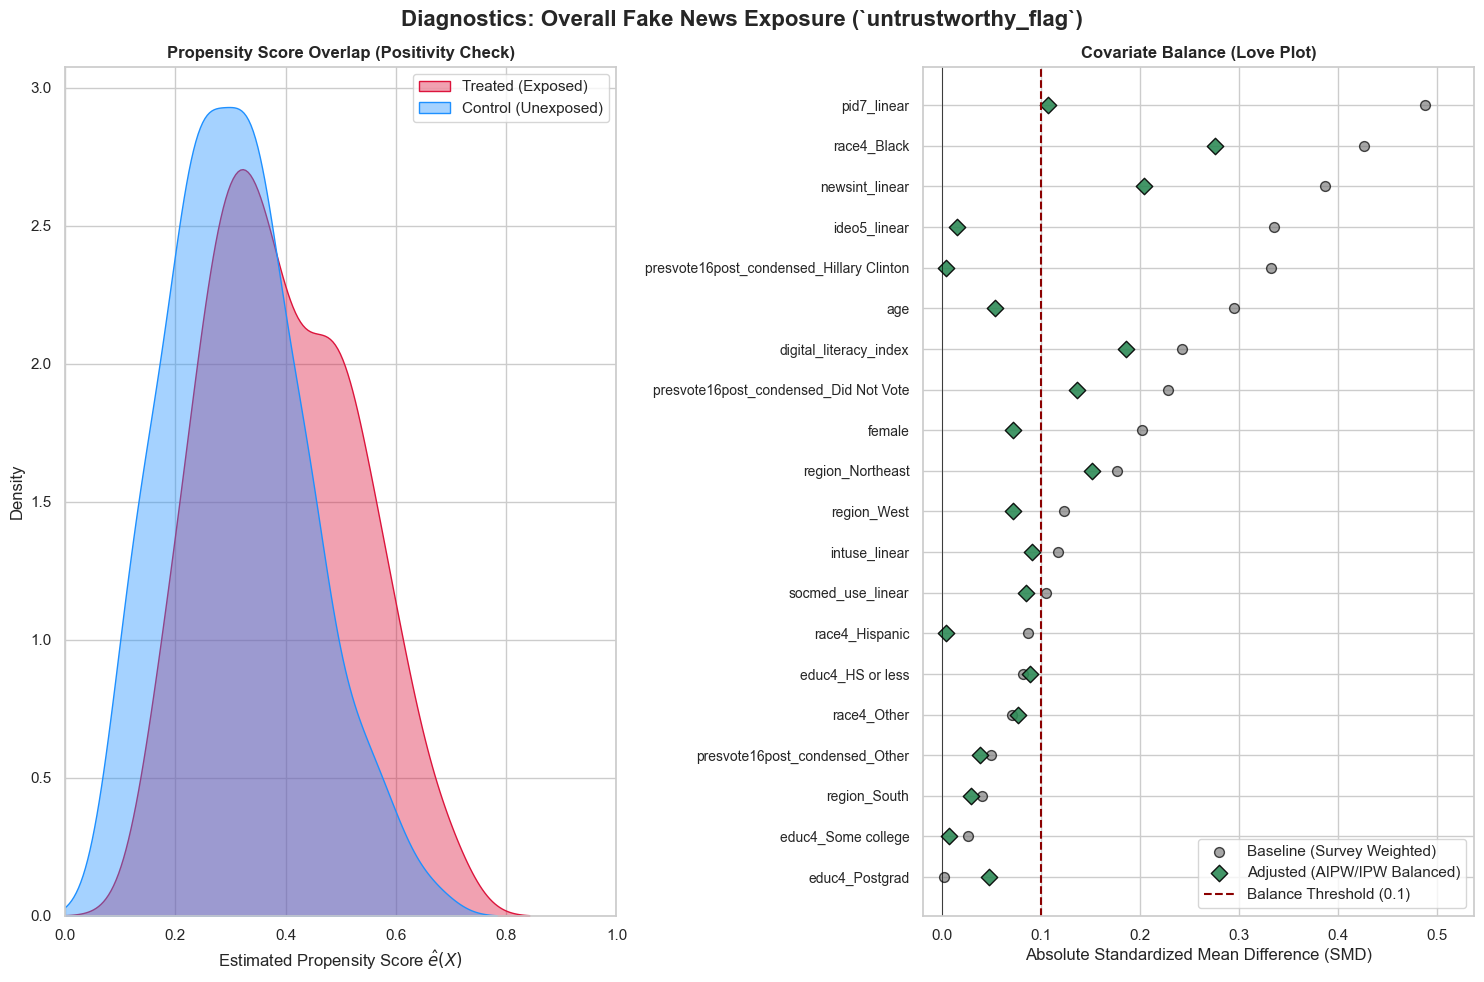

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
treatment = "untrustworthy_flag"

categorical_covariates = ["race4", "educ4", "region", "presvote16post_condensed"]
linear_features = ["ideo5_linear", "pid7_linear", "socmed_use_linear", "newsint_linear", "intuse_linear"]
engineered_continuous = ["digital_literacy_index"]
outcome_cols = list(outcomes.values())


all_needed_cols = (
    [treatment] + outcome_cols + ["age", "female", "weight_post"] + 
    engineered_continuous + linear_features + categorical_covariates
)


df_diag_clean = df[all_needed_cols].dropna().copy()


X_matrix_diag = pd.get_dummies(
    df_diag_clean[["age", "female"] + engineered_continuous + linear_features + categorical_covariates],
    columns=categorical_covariates,
    drop_first=False,
    dtype=int,
)


baselines_to_drop = [
    'presvote16post_condensed_Donald Trump',
    'race4_White',
    'educ4_College grad',
    'region_Midwest',
]
X_matrix_diag = X_matrix_diag.drop(columns=baselines_to_drop, errors='ignore')
covariate_names = X_matrix_diag.columns.tolist()


X_all = X_matrix_diag.values
W_all = df_diag_clean[treatment].astype(int).values
N_all = len(W_all)


raw_weights = df_diag_clean["weight_post"].values
low_b = np.percentile(raw_weights, 5)
upp_b = np.percentile(raw_weights, 95)
survey_weights_diag = np.clip(raw_weights, low_b, upp_b)
survey_weights_diag = survey_weights_diag / np.mean(survey_weights_diag)


def calculate_weighted_smd(X, W, weights):
    idx1 = (W == 1)
    idx0 = (W == 0)
    
    
    m1 = np.average(X[idx1], axis=0, weights=weights[idx1])
    m0 = np.average(X[idx0], axis=0, weights=weights[idx0])
    
    
    v1 = np.average((X[idx1] - m1)**2, axis=0, weights=weights[idx1])
    v0 = np.average((X[idx0] - m0)**2, axis=0, weights=weights[idx0])
    
    
    smd = (m1 - m0) / np.sqrt((v1 + v0) / 2.0 + 1e-10)
    return np.abs(smd)




np.random.seed(42)
indices = np.arange(N_all)
np.random.shuffle(indices)
folds = np.array_split(indices, 5)
e_hat = np.zeros(N_all)

for f in range(5):
    val_idx = folds[f]
    train_idx = np.setdiff1d(indices, val_idx)
    
    
    w_train = survey_weights_diag[train_idx] / np.mean(survey_weights_diag[train_idx])
    
    prop_model = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=10, random_state=42, n_jobs=-1)
    prop_model.fit(X_all[train_idx], W_all[train_idx], sample_weight=w_train)
    e_hat[val_idx] = prop_model.predict_proba(X_all[val_idx])[:, 1]
    
e_hat_clipped = np.clip(e_hat, 0.05, 0.95)


ipw_factors = (W_all / e_hat_clipped) + ((1 - W_all) / (1 - e_hat_clipped))
weights_ipw = survey_weights_diag * ipw_factors
weights_ipw = weights_ipw / np.mean(weights_ipw)


smd_baseline = calculate_weighted_smd(X_all, W_all, survey_weights_diag)
smd_adjusted = calculate_weighted_smd(X_all, W_all, weights_ipw)

df_smd = pd.DataFrame({
    'Covariate': covariate_names,
    'Baseline (Survey Weighted)': smd_baseline,
    'Adjusted (AIPW/IPW Balanced)': smd_adjusted
}).sort_values(by='Baseline (Survey Weighted)', ascending=True)




fig, axes = plt.subplots(1, 2, figsize=(15, 6 + 0.2 * len(covariate_names)))
fig.suptitle("Diagnostics: Overall Fake News Exposure (`untrustworthy_flag`)", fontsize=16, fontweight='bold', y=0.98)


sns.kdeplot(x=e_hat[W_all == 1], weights=survey_weights_diag[W_all == 1], fill=True, color='crimson', alpha=0.4, label='Treated (Exposed)', ax=axes[0], common_norm=False)
sns.kdeplot(x=e_hat[W_all == 0], weights=survey_weights_diag[W_all == 0], fill=True, color='dodgerblue', alpha=0.4, label='Control (Unexposed)', ax=axes[0], common_norm=False)
axes[0].set_title("Propensity Score Overlap (Positivity Check)", fontsize=12, fontweight='semibold')
axes[0].set_xlabel("Estimated Propensity Score $\hat{e}(X)$")
axes[0].set_ylabel("Density")
axes[0].set_xlim(0, 1)
axes[0].legend(frameon=True)


y_pos = np.arange(len(df_smd))
axes[1].scatter(df_smd['Baseline (Survey Weighted)'], y_pos, color='grey', alpha=0.7, label='Baseline (Survey Weighted)', edgecolors='black', s=50)
axes[1].scatter(df_smd['Adjusted (AIPW/IPW Balanced)'], y_pos, color='seagreen', alpha=0.9, label='Adjusted (AIPW/IPW Balanced)', edgecolors='black', s=70, marker='D')

axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(df_smd['Covariate'], fontsize=10)
axes[1].axvline(x=0.1, color='darkred', linestyle='--', linewidth=1.5, label='Balance Threshold (0.1)')
axes[1].axvline(x=0.0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_title("Covariate Balance (Love Plot)", fontsize=12, fontweight='semibold')
axes[1].set_xlabel("Absolute Standardized Mean Difference (SMD)")
axes[1].set_xlim(-0.02, max(df_smd['Baseline (Survey Weighted)'].max() + 0.05, 0.15))
axes[1].legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

--- GENERATING RAW WEIGHTED HISTOGRAM (0 ISOLATED, CAPPED AT 100) ---


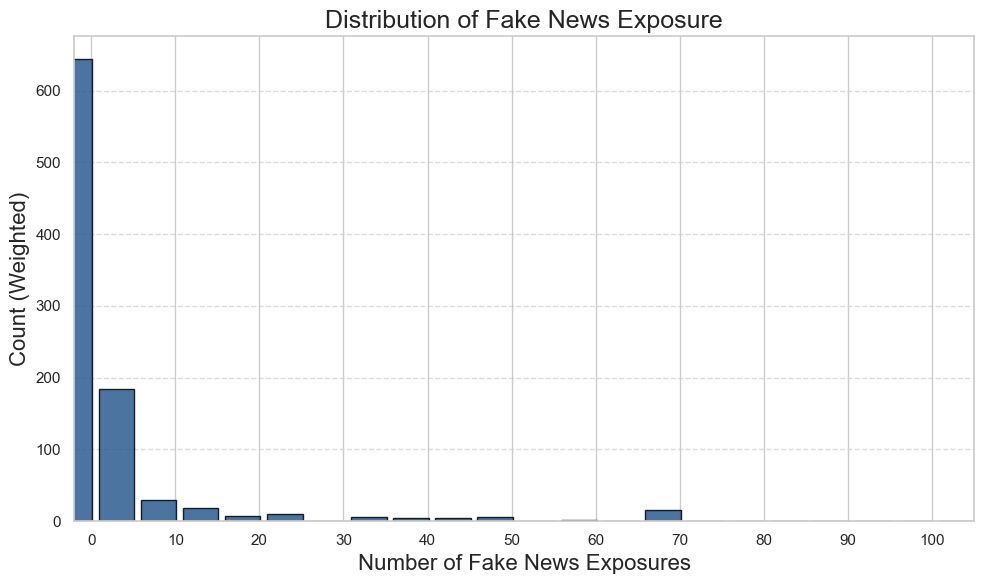

In [ ]:


df_filtered = df.loc[df.index.isin(X_matrix.index)]

clean_df = df_filtered[['untrustworthy_n', 'weight_post']].dropna()

counts = clean_df['untrustworthy_n'].values
weights = clean_df['weight_post'].values




bins = np.concatenate([[-4.5], np.arange(0.5, 111, 5)])

fig, ax = plt.subplots(figsize=(10, 6))


counts_output, bins_output, patches = ax.hist(
    counts,
    bins=bins,
    weights=weights,
    color='
    edgecolor='black',
    alpha=0.85,
    rwidth=0.85  
)


ax.set_title("Distribution of Fake News Exposure", fontsize=18)
ax.set_xlabel("Number of Fake News Exposures", fontsize=16)
ax.set_ylabel("Count (Weighted)", fontsize=16)


ax.set_xlim(-2, 105)


ax.set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
    

ax.yaxis.grid(True, linestyle='--', alpha=0.7, color='
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

--- GENERATING CAUSAL ESTIMATES FOREST PLOT (HOLLOW INSIGNIFICANT DOTS) ---


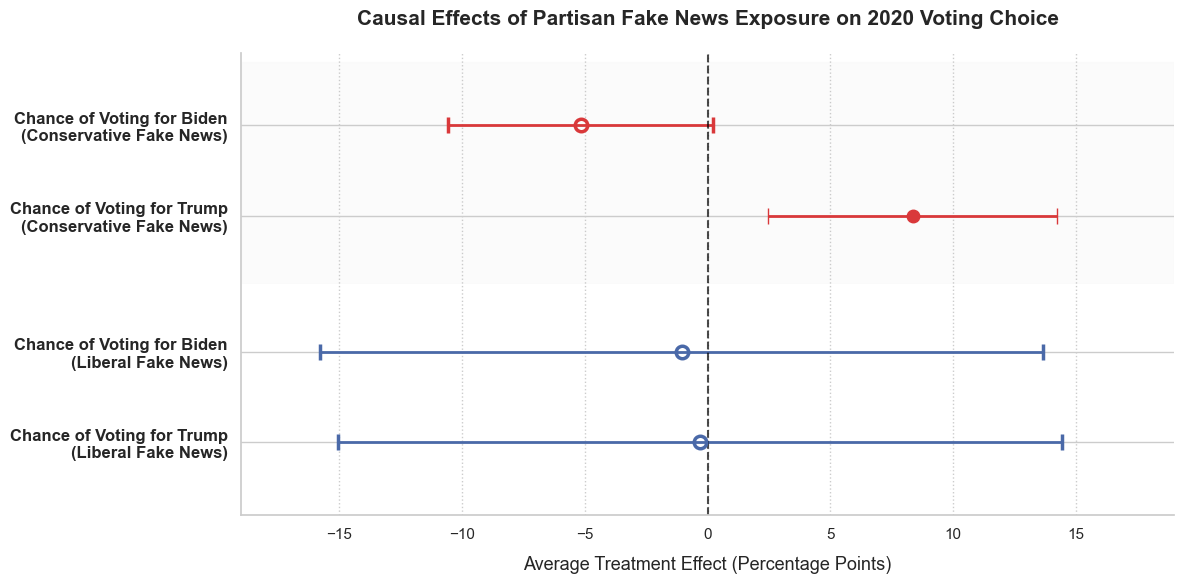

In [ ]:


labels = [
    "Chance of Voting for Biden\n(Conservative Fake News)",
    "Chance of Voting for Trump\n(Conservative Fake News)",
    "Chance of Voting for Biden\n(Liberal Fake News)",
    "Chance of Voting for Trump\n(Liberal Fake News)"
]

estimates = np.array([-5.17, 8.35, -1.06, -0.31])
ci_lower = np.array([-10.58, 2.46, -15.81, -15.04])
ci_upper = np.array([0.23, 14.23, 13.68, 14.42])


error_left = estimates - ci_lower
error_right = ci_upper - estimates
asymmetric_error = np.array([error_left, error_right])


y_positions = np.array([3.5, 2.5, 1.0, 0.0])


colors = ['




fig, ax = plt.subplots(figsize=(12, 6))


for i, y in enumerate(y_positions):
    
    is_insignificant = (ci_lower[i] < 0) and (ci_upper[i] > 0)
    
    
    m_face_color = "None" if is_insignificant else colors[i]
    m_edge_width = 2.5 if is_insignificant else 1.0
    
    
    ax.errorbar(
        estimates[i], y, 
        xerr=asymmetric_error[:, i:i+1], 
        fmt='o', 
        color=colors[i],
        markerfacecolor=m_face_color,  
        markeredgecolor=colors[i], 
        markeredgewidth=m_edge_width,
        markersize=9, 
        capsize=6, 
        capthick=2, 
        elinewidth=2,
        label=labels[i]
    )


ax.axvline(x=0.0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)





ax.set_yticks(y_positions)
ax.set_yticklabels(labels, fontsize=12, fontweight='semibold')
ax.set_ylim(-0.8, 4.3)


ax.set_xlim(-19, 19)
ax.set_xlabel("Average Treatment Effect (Percentage Points)", fontsize=13, labelpad=10)
ax.set_title("Causal Effects of Partisan Fake News Exposure on 2020 Voting Choice", fontsize=15, pad=20, weight='bold')


ax.axhspan(1.75, 4.2, color='
ax.axhspan(-0.6, 1.75, color='


ax.xaxis.grid(True, linestyle=':', alpha=0.6, color='
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('

plt.tight_layout()
plt.show()